# 11. Evaluate Shared-E2E Encoder-Representation Projected

동일한 VOC2007 validation split에서 `baseline`, `shared_e2e`, `shared_e2e_rep_projected`의 현재 seed 42/43/44 checkpoint를 직접 재추론합니다. 새 모델은 encoder parameter 전체가 아니라 공유 encoder 출력 representation에서 conflict surgery를 수행합니다. 평가는 서로 섞이지 않는 세 묶음으로 나눕니다.

- Detection: semantic mAP/AP50/AP75/AR100
- Localization: 모든 label을 object로 통일한 AP, matched IoU, center/size error
- Classification: training과 같은 Hungarian match의 query class accuracy와 GT score, focal classification loss, IoU 0.5에서의 classification FP

Classification FP는 score 0.1 이상 detection 중 가장 가까운 GT와 IoU가 0.5 이상이지만 class가 다른 경우로 명시적으로 정의합니다. VOC smoke checkpoint의 score 분포에서 0.5는 detection이 거의 남지 않으므로 0.1을 고정합니다.

In [1]:
from pathlib import Path
import gc, importlib, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import gt_aux.model as model_module
import gt_aux.eval as eval_module
config_module = importlib.reload(config_module)
data_module = importlib.reload(data_module)
model_module = importlib.reload(model_module)
eval_module = importlib.reload(eval_module)

ExperimentConfig = config_module.ExperimentConfig
prepare_data, make_loaders = data_module.prepare_data, data_module.make_loaders
load_checkpoint = eval_module.load_checkpoint
evaluate_main = eval_module.evaluate_main
collect_localization_predictions = eval_module.collect_localization_predictions
localization_metrics = eval_module.localization_metrics
localization_geometry_metrics = eval_module.localization_geometry_metrics
classification_diagnostics = eval_module.classification_diagnostics

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 평가 설정과 checkpoint 무결성

학습 노트북과 같은 split, image size, batch size를 사용합니다. 하나라도 없거나 7 epoch 미만이면 중단해 불완전한 모델이 평균에 섞이지 않게 합니다.

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'shared_e2e', 'shared_e2e_rep_projected']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 2, 384, 640
CLASSIFICATION_SCORE_THRESHOLD = 0.1
CLASSIFICATION_IOU_THRESHOLD = 0.5
RUN_INFERENCE = False  # Existing raw evaluation CSV is reused for plotting.
STRICT_CHECKPOINTS = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, image_min_size=IMAGE_MIN_SIZE,
    image_max_size=IMAGE_MAX_SIZE, feature_level=0, base_aux_weight=0.5,
)
CONFIG.as_dict()

{'root': 'D:\\gt-super',
 'run_mode': 'smoke',
 'checkpoint': 'SenseTime/deformable-detr',
 'train_images': 400,
 'val_images': 100,
 'epochs': 7,
 'batch_size': 2,
 'num_workers': 0,
 'image_size': {'shortest_edge': 384, 'longest_edge': 640},
 'lr': 0.0002,
 'backbone_lr': 2e-05,
 'weight_decay': 0.0001,
 'grad_clip': 0.1,
 'base_aux_weight': 0.5,
 'feature_level': 0,
 'horizontal_flip_p': 0.5,
 'use_amp': True,
 'deterministic': True,
 'save_epoch_checkpoints': False,
 'device': 'cuda',
 'experiments': ['baseline', 'shared_e2e', 'shared_e2e_rep_projected'],
 'seed': 42,
 'data_seed': 42}

In [3]:
BUNDLE = prepare_data(CONFIG)
checkpoint_rows = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        path = CONFIG.checkpoint_path(experiment, seed)
        epoch = None
        history_path = CONFIG.history_path(experiment, seed)
        if history_path.exists():
            history = pd.read_csv(history_path)
            epoch = int(history['epoch'].max()) if not history.empty else None
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed, 'exists': path.exists(),
            'epoch': epoch, 'path': str(path),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
invalid = checkpoint_df[(~checkpoint_df['exists']) | (checkpoint_df['epoch'] != EPOCHS)]
if STRICT_CHECKPOINTS and not invalid.empty:
    raise FileNotFoundError(
        'Missing or incomplete checkpoints. Run 01_train_experiments.ipynb and '
        '01-3_train_shared_e2e_projected.ipynb first:\n' +
        '\n'.join(invalid['path'])
    )

VOC XML: 100%|██████████| 3750/3750 [00:01<00:00, 3018.57it/s]

Full split: train=3000 (9180 objects), val=750 (2530 objects)
Current run: train=400, val=100


,experiment,seed,exists,epoch,path
0,baseline,42,True,7,D:\gt-super\cache\checkpoints\baseline\seed_42...
1,baseline,43,True,7,D:\gt-super\cache\checkpoints\baseline\seed_43...
2,baseline,44,True,7,D:\gt-super\cache\checkpoints\baseline\seed_44...
3,shared_e2e,42,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
4,shared_e2e,43,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
5,shared_e2e,44,True,7,D:\gt-super\cache\checkpoints\shared_e2e\seed_...
6,shared_e2e_rep_projected,42,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...
7,shared_e2e_rep_projected,43,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...
8,shared_e2e_rep_projected,44,True,7,D:\gt-super\cache\checkpoints\shared_e2e_rep_p...


## 2. 현재 checkpoint 직접 재평가

각 모델을 한 번에 하나만 GPU에 올리고 평가 후 즉시 해제합니다. 과거 notebook output이나 종합 cache의 metric은 재사용하지 않습니다.

In [4]:
RAW_PATH = CONFIG.output_dir / 'shared_e2e_projected_evaluation_raw.csv'
rows = []
if RUN_INFERENCE:
    for experiment in EXPERIMENTS:
        for seed in SEEDS:
            print(f'[{experiment} / seed={seed}]')
            _, val_loader = make_loaders(CONFIG, BUNDLE, seed)
            model, checkpoint, fingerprint = load_checkpoint(CONFIG, BUNDLE, experiment, seed)
            predictions = targets = None
            try:
                detection = evaluate_main(model, val_loader, BUNDLE.processor, CONFIG)
                predictions, targets = collect_localization_predictions(
                    model, val_loader, BUNDLE.processor, CONFIG
                )
                localization = {
                    **localization_metrics(predictions, targets),
                    **localization_geometry_metrics(predictions, targets, max_detections=100),
                }
                classification = classification_diagnostics(
                    model, val_loader, BUNDLE.processor, CONFIG,
                    score_threshold=CLASSIFICATION_SCORE_THRESHOLD,
                    iou_threshold=CLASSIFICATION_IOU_THRESHOLD,
                )
                row = {
                    'experiment': experiment, 'seed': seed,
                    'checkpoint_epoch': checkpoint.get('epoch'),
                    'fingerprint': fingerprint, **detection, **localization, **classification,
                }
                rows.append(row)
                print({key: round(value, 4) for key, value in row.items() if key in {
                    'map', 'map75', 'loc_ap75', 'matched_iou',
                    'matched_query_class_accuracy', 'mean_cls_loss',
                    'classification_fp_per_image',
                }})
            finally:
                model.close()
                model.cpu()
                del model, checkpoint, predictions, targets
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
    results_df = pd.DataFrame(rows)
    results_df.to_csv(RAW_PATH, index=False)
else:
    results_df = pd.read_csv(RAW_PATH)
print('Saved/loaded:', RAW_PATH)
display(results_df)

Saved/loaded: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_evaluation_raw.csv


,experiment,seed,checkpoint_epoch,fingerprint,map,map50,map75,mar100,val_seconds,loc_map,...,matched_query_mean_gt_score,matched_queries,classification_fp_count,classification_fp_per_image,classification_fp_rate,background_fp_count,background_fp_per_image,detections_at_threshold,classification_score_threshold,classification_iou_threshold
0,baseline,42,7,c16286f63961237b,0.059872,0.110153,0.059278,0.391496,5.596728,0.125056,...,0.109335,311,899,8.99,0.281995,976,9.76,3188,0.1,0.5
1,baseline,43,7,d1b7a9f86e187c5e,0.103289,0.162047,0.109564,0.437702,5.255085,0.179728,...,0.118440,311,1869,18.69,0.485455,871,8.71,3850,0.1,0.5
2,baseline,44,7,9fffb715f8680daa,0.043373,0.081491,0.046653,0.334737,5.253709,0.108407,...,0.103377,311,889,8.89,0.296333,989,9.89,3000,0.1,0.5
3,shared_e2e,42,7,c16286f63961237b,0.069646,0.114608,0.075431,0.394205,5.166220,0.144485,...,0.117985,311,1476,14.76,0.379142,1115,11.15,3893,0.1,0.5
4,shared_e2e,43,7,d1b7a9f86e187c5e,0.107322,0.170547,0.105593,0.404736,5.250383,0.155968,...,0.116757,311,1736,17.36,0.435415,932,9.32,3987,0.1,0.5
5,shared_e2e,44,7,9fffb715f8680daa,0.063477,0.104559,0.063565,0.411831,5.206245,0.124314,...,0.109700,311,1359,13.59,0.383790,961,9.61,3541,0.1,0.5
6,shared_e2e_rep_projected,42,7,c16286f63961237b,0.094562,0.160022,0.101423,0.427689,5.290398,0.166000,...,0.121685,311,1406,14.06,0.375234,1047,10.47,3747,0.1,0.5
7,shared_e2e_rep_projected,43,7,d1b7a9f86e187c5e,0.126917,0.189808,0.141917,0.481243,5.247478,0.155867,...,0.123968,311,1853,18.53,0.426369,1145,11.45,4346,0.1,0.5
8,shared_e2e_rep_projected,44,7,9fffb715f8680daa,0.061714,0.106904,0.065998,0.395605,5.218663,0.106465,...,0.109125,311,1028,10.28,0.318957,923,9.23,3223,0.1,0.5


## 3. 세 축 평균·표준편차와 paired seed delta

평균만 보지 않고 같은 initialization seed끼리 `projected - reference`를 계산합니다. error/loss/FP 계열은 음수 delta가 개선입니다.

In [5]:
DETECTION_METRICS = ['map', 'map50', 'map75', 'mar100']
LOCALIZATION_METRICS = [
    'loc_map', 'loc_ap50', 'loc_ap75', 'loc_ar100',
    'loc_ap_small', 'loc_ap_medium', 'loc_ap_large',
    'matched_iou', 'center_error_l2', 'size_error_l1',
    'geometry_recall50', 'geometry_recall75',
]
CLASSIFICATION_METRICS = [
    'matched_query_class_accuracy', 'matched_query_mean_gt_score',
    'mean_cls_loss', 'classification_fp_per_image',
    'classification_fp_rate', 'background_fp_per_image',
]
ALL_METRICS = DETECTION_METRICS + LOCALIZATION_METRICS + CLASSIFICATION_METRICS
summary = results_df.groupby('experiment')[ALL_METRICS].agg(['mean', 'std', 'count'])
summary_path = CONFIG.output_dir / 'shared_e2e_projected_evaluation_summary.csv'
summary.to_csv(summary_path)
display(summary)
print('Saved:', summary_path)

delta_frames = []
projected = results_df.query("experiment == 'shared_e2e_rep_projected'").set_index('seed')[ALL_METRICS]
for reference in ['baseline', 'shared_e2e']:
    reference_df = results_df.query('experiment == @reference').set_index('seed')[ALL_METRICS]
    common = projected.index.intersection(reference_df.index)
    delta = projected.loc[common] - reference_df.loc[common]
    delta['reference'] = reference
    delta['seed'] = common
    delta_frames.append(delta.reset_index(drop=True))
paired_delta_df = pd.concat(delta_frames, ignore_index=True)
delta_path = CONFIG.output_dir / 'shared_e2e_projected_paired_deltas.csv'
paired_delta_df.to_csv(delta_path, index=False)
display(paired_delta_df.groupby('reference')[ALL_METRICS].agg(['mean', 'std']))
print('Saved:', delta_path)

map                     map50                  \
                              mean       std count      mean       std count   
experiment                                                                     
baseline                  0.068845  0.030949     3  0.117897  0.040832     3   
shared_e2e                0.080148  0.023734     3  0.129905  0.035554     3   
shared_e2e_rep_projected  0.094398  0.032602     3  0.152245  0.041995     3   

                             map75                    mar100  ...  \
                              mean       std count      mean  ...   
experiment                                                    ...   
baseline                  0.071832  0.033281     3  0.387978  ...   
shared_e2e                0.081530  0.021667     3  0.403591  ...   
shared_e2e_rep_projected  0.103113  0.037988     3  0.434845  ...   

                         mean_cls_loss classification_fp_per_image            \
                                 count                        mean       std   
experiment                                                                     
baseline                             3                   12.190000  5.629387   
shared_e2e                           3                   15.236667  1.929672   
shared_e2e_rep_projected             3                   14.290000  4.129806   

                               classification_fp_rate                  \
                         count                   mean       std count   
experiment                                                              
baseline                     3               0.354594  0.113555     3   
shared_e2e                   3               0.399449  0.031234     3   
shared_e2e_rep_projected     3               0.373520  0.053726     3   

                         background_fp_per_image                  
                                            mean       std count  
experiment                                                        
baseline                                9.453333  0.647019     3  
shared_e2e                             10.026667  0.983582     3  
shared_e2e_rep_projected               10.383333  1.112535     3  

[3 rows x 66 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_evaluation_summary.csv


map               map50               map75            \
                mean       std      mean       std      mean       std   
reference                                                                
baseline    0.025553  0.008343  0.034348  0.013493  0.031281  0.011438   
shared_e2e  0.014250  0.014120  0.022340  0.021699  0.021583  0.017371   

              mar100             loc_map            ...  \
                mean       std      mean       std  ...   
reference                                           ...   
baseline    0.046867  0.012669  0.005047  0.032963  ...   
shared_e2e  0.031255  0.046406  0.001189  0.019714  ...   

           matched_query_mean_gt_score           mean_cls_loss            \
                                  mean       std          mean       std   
reference                                                                  
baseline                      0.007876  0.003877     -0.026197  0.027383   
shared_e2e                    0.003445  0.003899     -0.008431  0.014609   

           classification_fp_per_image           classification_fp_rate  \
                                  mean       std                   mean   
reference                                                                 
baseline                      2.100000  2.686317               0.018926   
shared_e2e                   -0.946667  2.250163              -0.025929   

                     background_fp_per_image            
                 std                    mean       std  
reference                                               
baseline    0.076229                0.930000  1.710643  
shared_e2e  0.033789                0.356667  1.543060  

[2 rows x 44 columns]

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_paired_deltas.csv


## 4. Gradient mechanism과 성능 변화 연결

Projected 모델의 step log에서 epoch conflict rate와 제거 비율을 다시 계산합니다. 이 값은 projection이 실제로 언제/얼마나 작동했는지 보여 주며 AP 자체와 다른 mechanism evidence입니다.

In [6]:
gradient_frames = []
for seed in SEEDS:
    path = CONFIG.gradients_path('shared_e2e_rep_projected', seed)
    if not path.exists():
        raise FileNotFoundError(path)
    gradient_frames.append(pd.read_csv(path))
gradient_df = pd.concat(gradient_frames, ignore_index=True)
gradient_df['projection_applied_on_update'] = gradient_df['projection_applied'].where(
    ~gradient_df['optimizer_step_skipped'].astype(bool)
)
mechanism_df = gradient_df.groupby(['seed', 'epoch']).agg(
    conflict_rate=('projection_applied', 'mean'),
    update_conflict_rate=('projection_applied_on_update', 'mean'),
    optimizer_skip_rate=('optimizer_step_skipped', 'mean'),
    raw_cosine_mean=('enc_cls_aux_cosine_raw', 'mean'),
    raw_cosine_median=('enc_cls_aux_cosine_raw', 'median'),
    removed_ratio_mean=('projection_removed_ratio', 'mean'),
    cls_norm_mean=('enc_cls_grad_norm', 'mean'),
    aux_norm_mean=('enc_aux_grad_norm', 'mean'),
    projected_aux_norm_mean=('enc_aux_grad_norm_projected', 'mean'),
    projection_vector_mb=('projection_vector_mb', 'mean'),
).reset_index()
mechanism_path = CONFIG.output_dir / 'shared_e2e_projected_evaluation_mechanism.csv'
mechanism_df.to_csv(mechanism_path, index=False)
display(mechanism_df)
print('Saved:', mechanism_path)

,seed,epoch,conflict_rate,update_conflict_rate,optimizer_skip_rate,raw_cosine_mean,raw_cosine_median,removed_ratio_mean,cls_norm_mean,aux_norm_mean,projected_aux_norm_mean,projection_vector_mb
0,42,1,0.545,0.544503,0.045,0.000184,-1.737825e-04,0.000004,0.229873,1.237849,1.237843,9.555127
1,42,2,0.465,0.465,0.000,0.000472,1.450042e-04,0.000010,0.017033,1.046699,1.046688,9.524912
2,42,3,0.410,0.41,0.000,0.001181,6.023087e-04,0.000009,0.021916,0.958674,0.958665,9.597393
3,42,4,0.365,0.365,0.000,0.001179,1.158485e-03,0.000010,0.022060,0.867185,0.867175,9.620654
4,42,5,0.450,0.45,0.000,0.001407,4.389717e-04,0.000006,0.023834,0.843601,0.843595,9.584980
5,42,6,0.445,0.445,0.000,0.001205,4.238903e-04,0.000016,0.025404,0.819940,0.819924,9.484033
6,42,7,0.465,0.465,0.000,0.000453,2.400598e-04,0.000012,0.025816,0.800512,0.800502,9.509326
7,43,1,0.520,0.52356,0.045,0.000347,-3.430823e-05,0.000003,0.152148,1.542237,1.542231,9.506611
8,43,2,0.450,0.45,0.000,0.000561,1.341913e-04,0.000010,0.016972,1.158139,1.158126,9.461973
9,43,3,0.470,0.47,0.000,0.001151,1.473849e-04,0.000006,0.020945,0.970236,0.970230,9.531582


Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_evaluation_mechanism.csv


## 5. Detection / Localization / Classification 시각화

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_evaluation.png


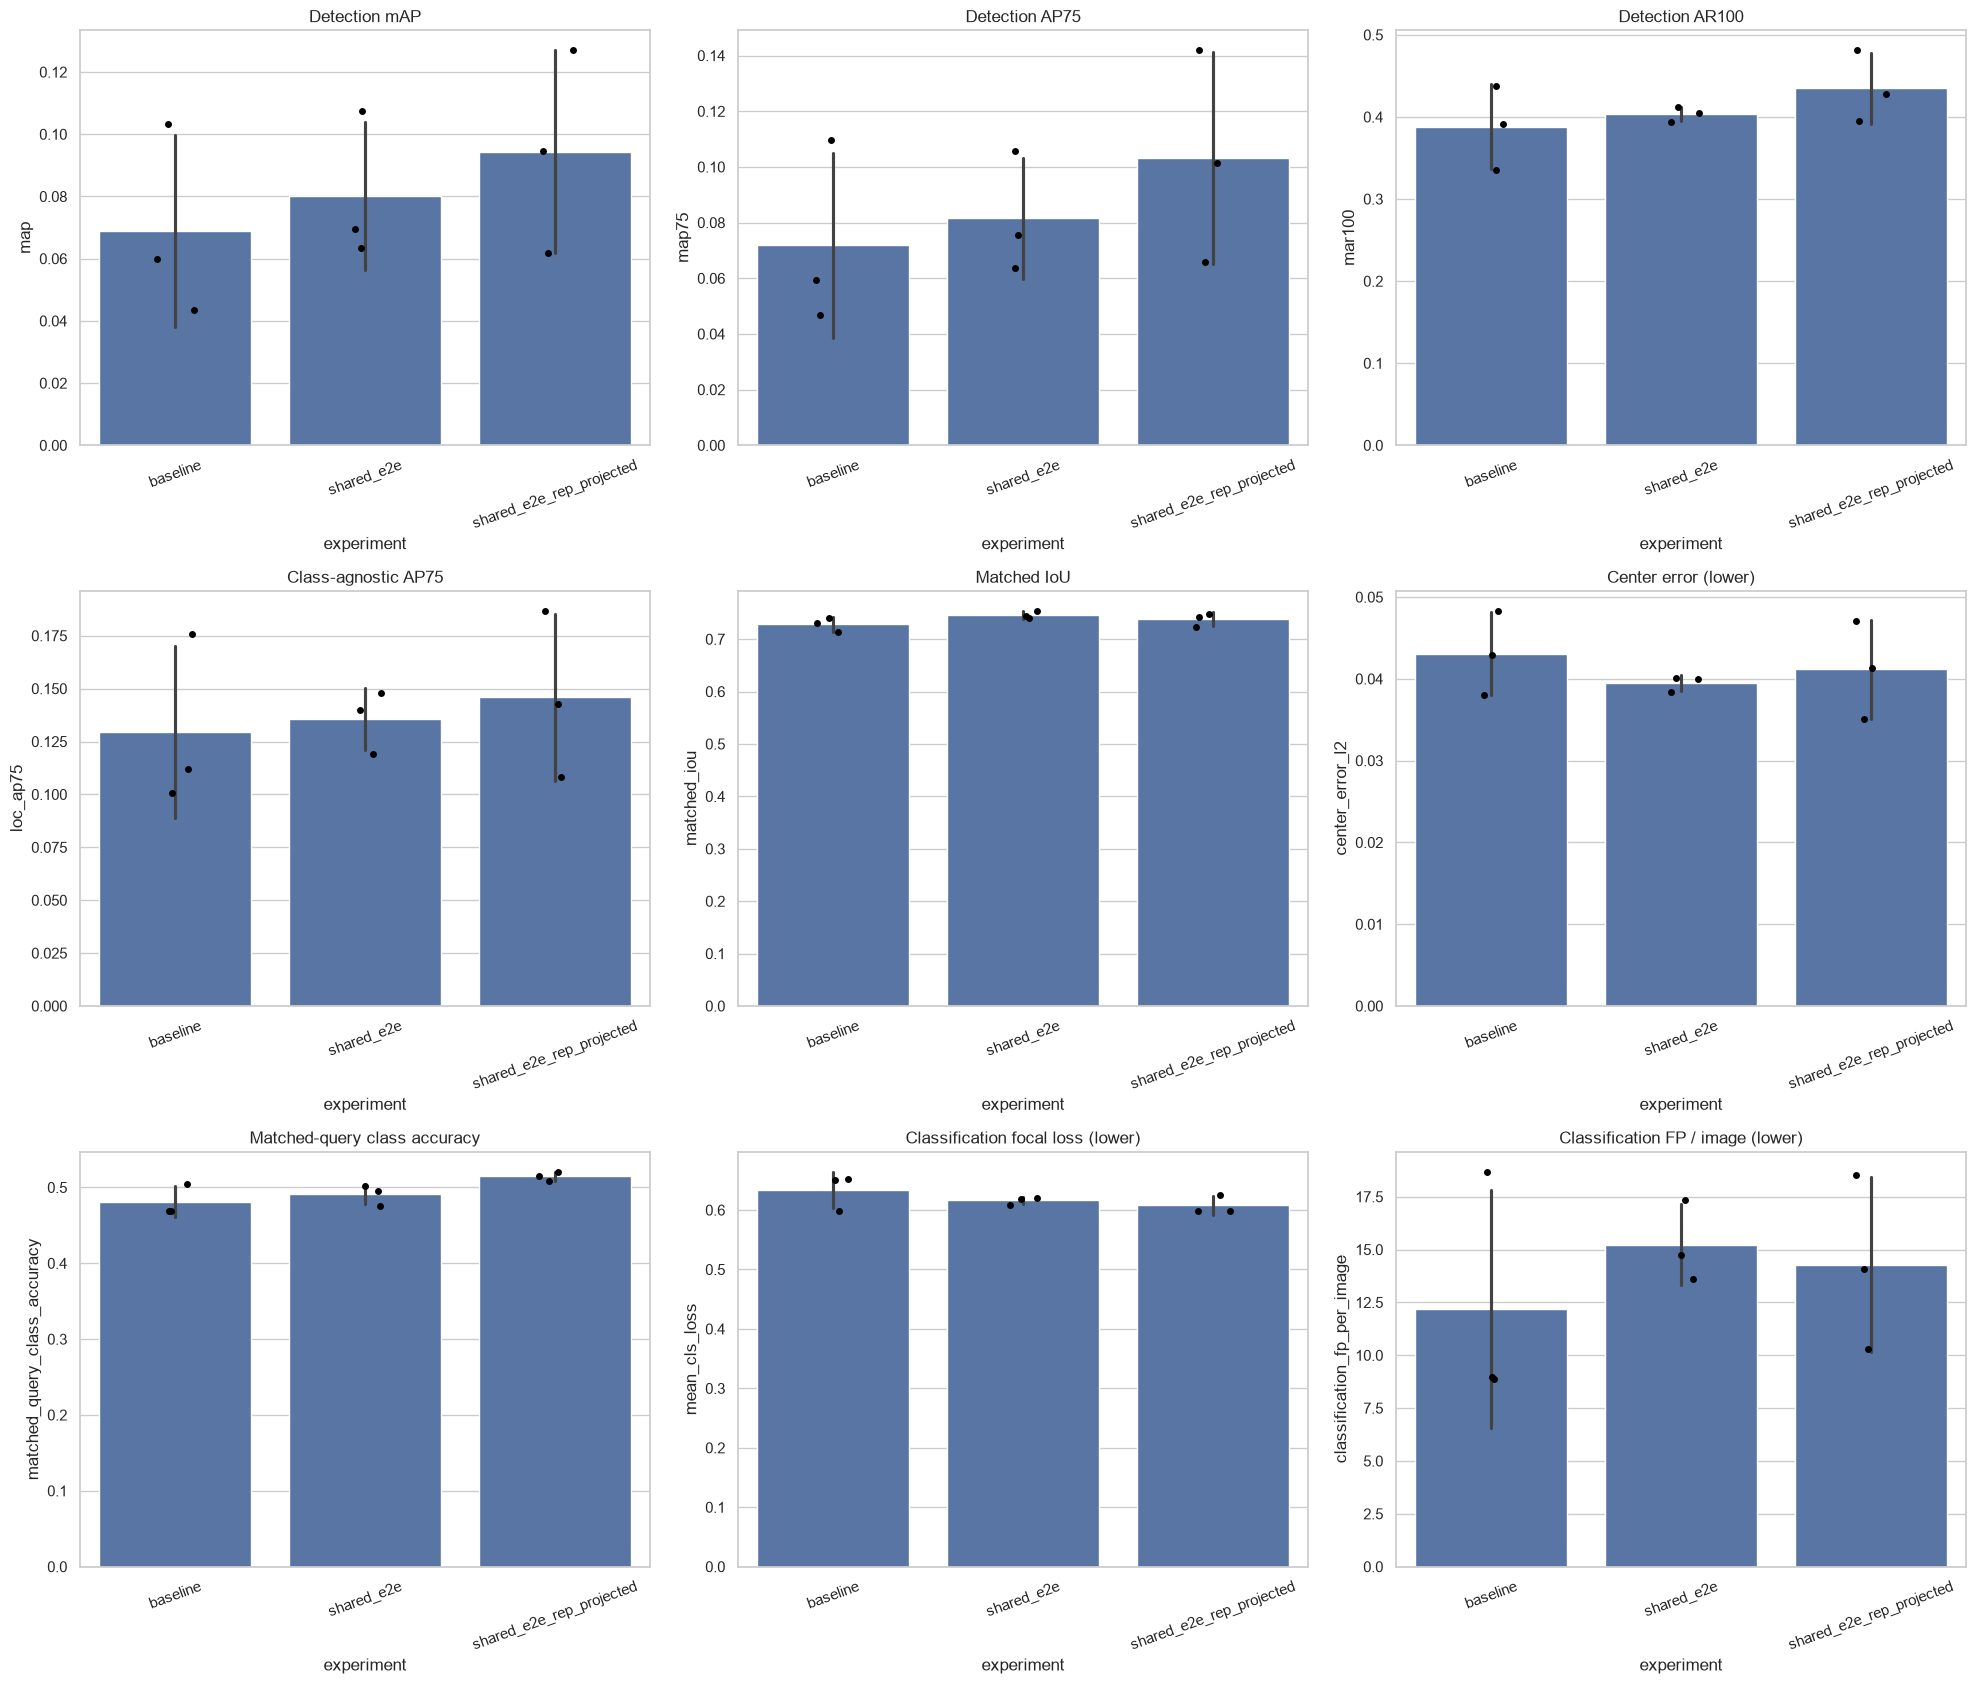

In [7]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 3, figsize=(20, 17))
plot_specs = [
    ('map', 'Detection mAP', False),
    ('map75', 'Detection AP75', False),
    ('mar100', 'Detection AR100', False),
    ('loc_ap75', 'Class-agnostic AP75', False),
    ('matched_iou', 'Matched IoU', False),
    ('center_error_l2', 'Center error (lower)', True),
    ('matched_query_class_accuracy', 'Matched-query class accuracy', False),
    ('mean_cls_loss', 'Classification focal loss (lower)', True),
    ('classification_fp_per_image', 'Classification FP / image (lower)', True),
]
for axis, (metric, title, lower_is_better) in zip(axes.flat, plot_specs):
    sns.barplot(data=results_df, x='experiment', y=metric, errorbar='sd', ax=axis)
    sns.stripplot(data=results_df, x='experiment', y=metric, color='black', size=5, ax=axis)
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()
figure_path = CONFIG.output_dir / 'shared_e2e_projected_evaluation.png'
fig.savefig(figure_path, dpi=180, bbox_inches='tight')
print('Saved:', figure_path)
plt.show()

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projected_mechanism.png


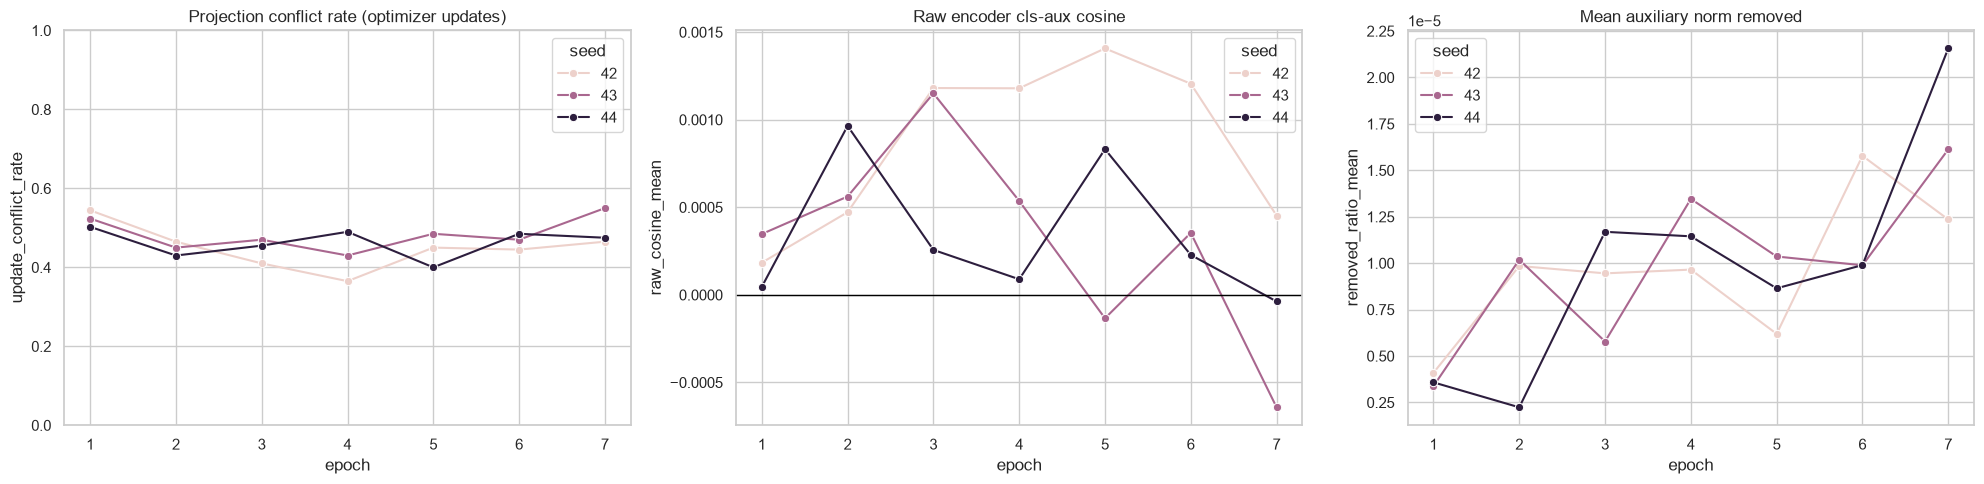

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.lineplot(data=mechanism_df, x='epoch', y='update_conflict_rate', hue='seed', marker='o', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Projection conflict rate (optimizer updates)')
sns.lineplot(data=mechanism_df, x='epoch', y='raw_cosine_mean', hue='seed', marker='o', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Raw encoder cls-aux cosine')
sns.lineplot(data=mechanism_df, x='epoch', y='removed_ratio_mean', hue='seed', marker='o', ax=axes[2])
axes[2].set_title('Mean auxiliary norm removed')
plt.tight_layout()
mechanism_figure_path = CONFIG.output_dir / 'shared_e2e_projected_mechanism.png'
fig.savefig(mechanism_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', mechanism_figure_path)
plt.show()

## 판정 기준

목표 패턴은 `Representation-Projected localization ≈ Shared-E2E > Baseline`이면서 `Representation-Projected classification ≈ Baseline > Shared-E2E`입니다. 다만 projection은 현재 mini-batch의 공유 encoder representation에서 auxiliary gradient가 classification gradient에 직접 반대되는 성분만 제거합니다. 최종 classification 성능을 수학적으로 보장하지 않으므로 세 seed의 paired delta, 표준편차, conflict rate와 01-3의 시간·peak memory probe를 함께 해석합니다.

## 6. Training convergence and loss curves

The checkpoint evaluation above is kept intact. These plots only read the saved per-epoch histories, so they do not rerun inference.

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projection_training_curves.png


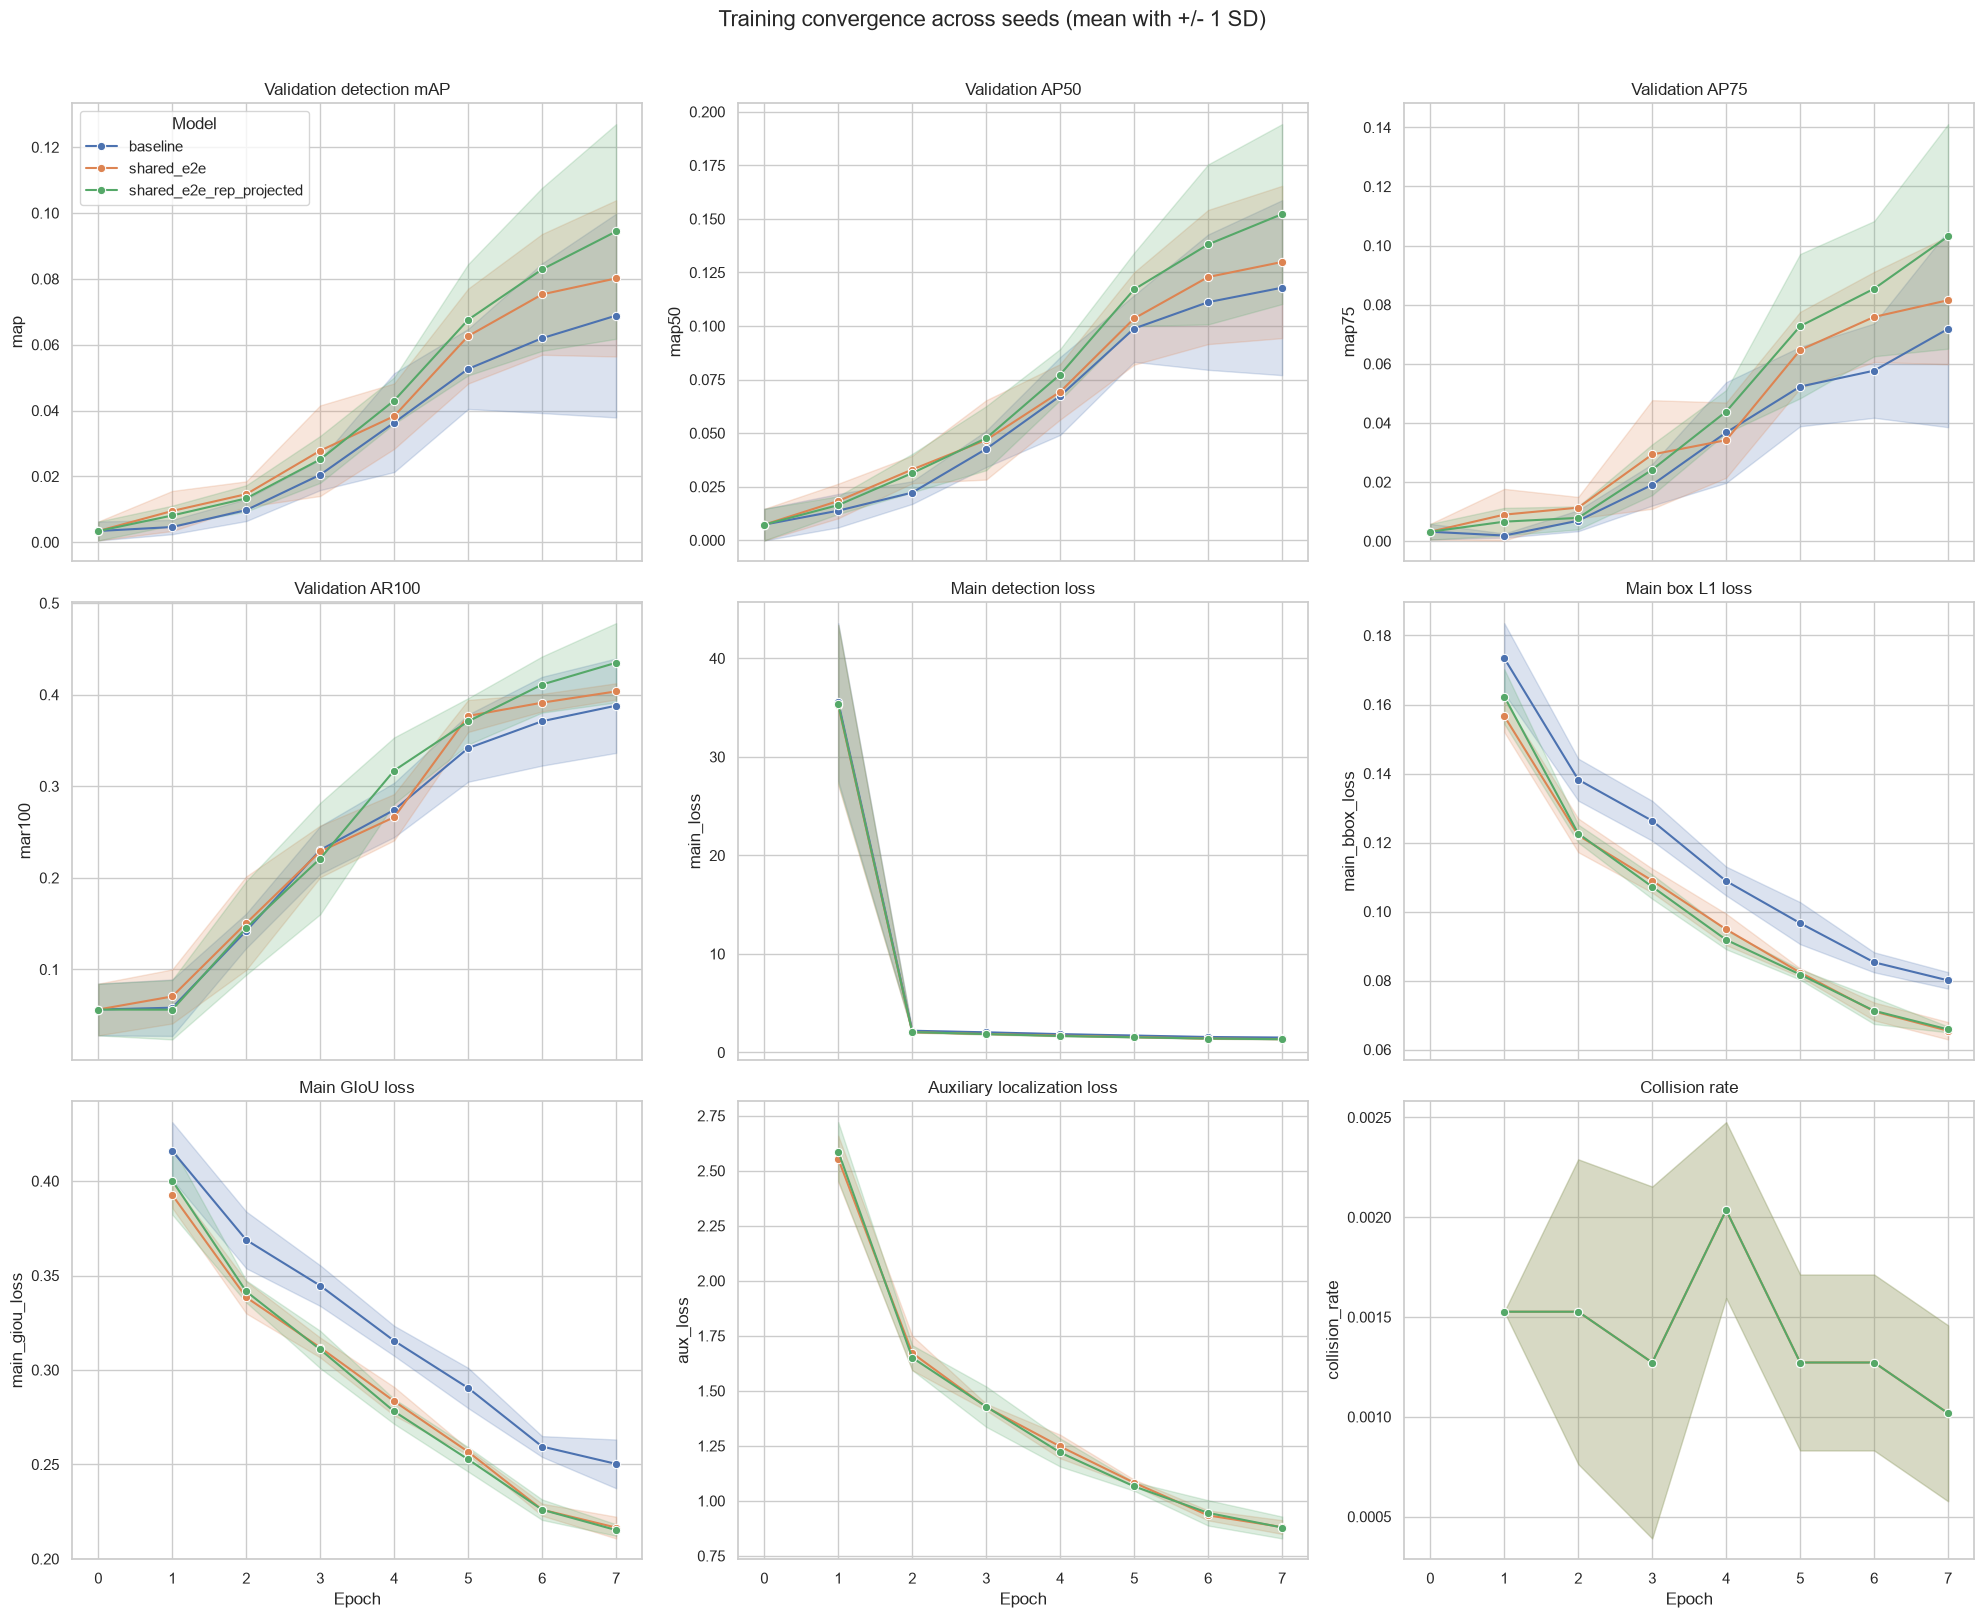

In [9]:
history_frames = []
for experiment in EXPERIMENTS:
    for seed in SEEDS:
        history_path = CONFIG.history_path(experiment, seed)
        if history_path.exists():
            frame = pd.read_csv(history_path).copy()
            frame['experiment'] = experiment
            frame['seed'] = seed
            history_frames.append(frame)

training_df = pd.concat(history_frames, ignore_index=True)
plot_specs = [
    ('map', 'Validation detection mAP'),
    ('map50', 'Validation AP50'),
    ('map75', 'Validation AP75'),
    ('mar100', 'Validation AR100'),
    ('main_loss', 'Main detection loss'),
    ('main_bbox_loss', 'Main box L1 loss'),
    ('main_giou_loss', 'Main GIoU loss'),
    ('aux_loss', 'Auxiliary localization loss'),
    ('collision_rate', 'Collision rate'),
]
fig, axes = plt.subplots(3, 3, figsize=(20, 16), sharex=True)
for index, (metric, title) in enumerate(plot_specs):
    ax = axes.flat[index]
    if metric not in training_df.columns:
        ax.set_axis_off()
        continue
    sns.lineplot(
        data=training_df, x='epoch', y=metric, hue='experiment',
        estimator='mean', errorbar='sd', marker='o', ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    if index != 0 and ax.legend_ is not None:
        ax.legend_.remove()
axes[0, 0].legend(title='Model', loc='best')
fig.suptitle('Training convergence across seeds (mean with +/- 1 SD)', y=1.01, fontsize=16)
plt.tight_layout()
training_figure_path = CONFIG.output_dir / 'shared_e2e_projection_training_curves.png'
fig.savefig(training_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', training_figure_path)
plt.show()

## 7. Paired seed-level effect of representation projection

Every point is one identical-seed comparison: `Representation-Projected - reference`. Negative deltas are desirable for error and loss metrics.

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projection_paired_deltas.png


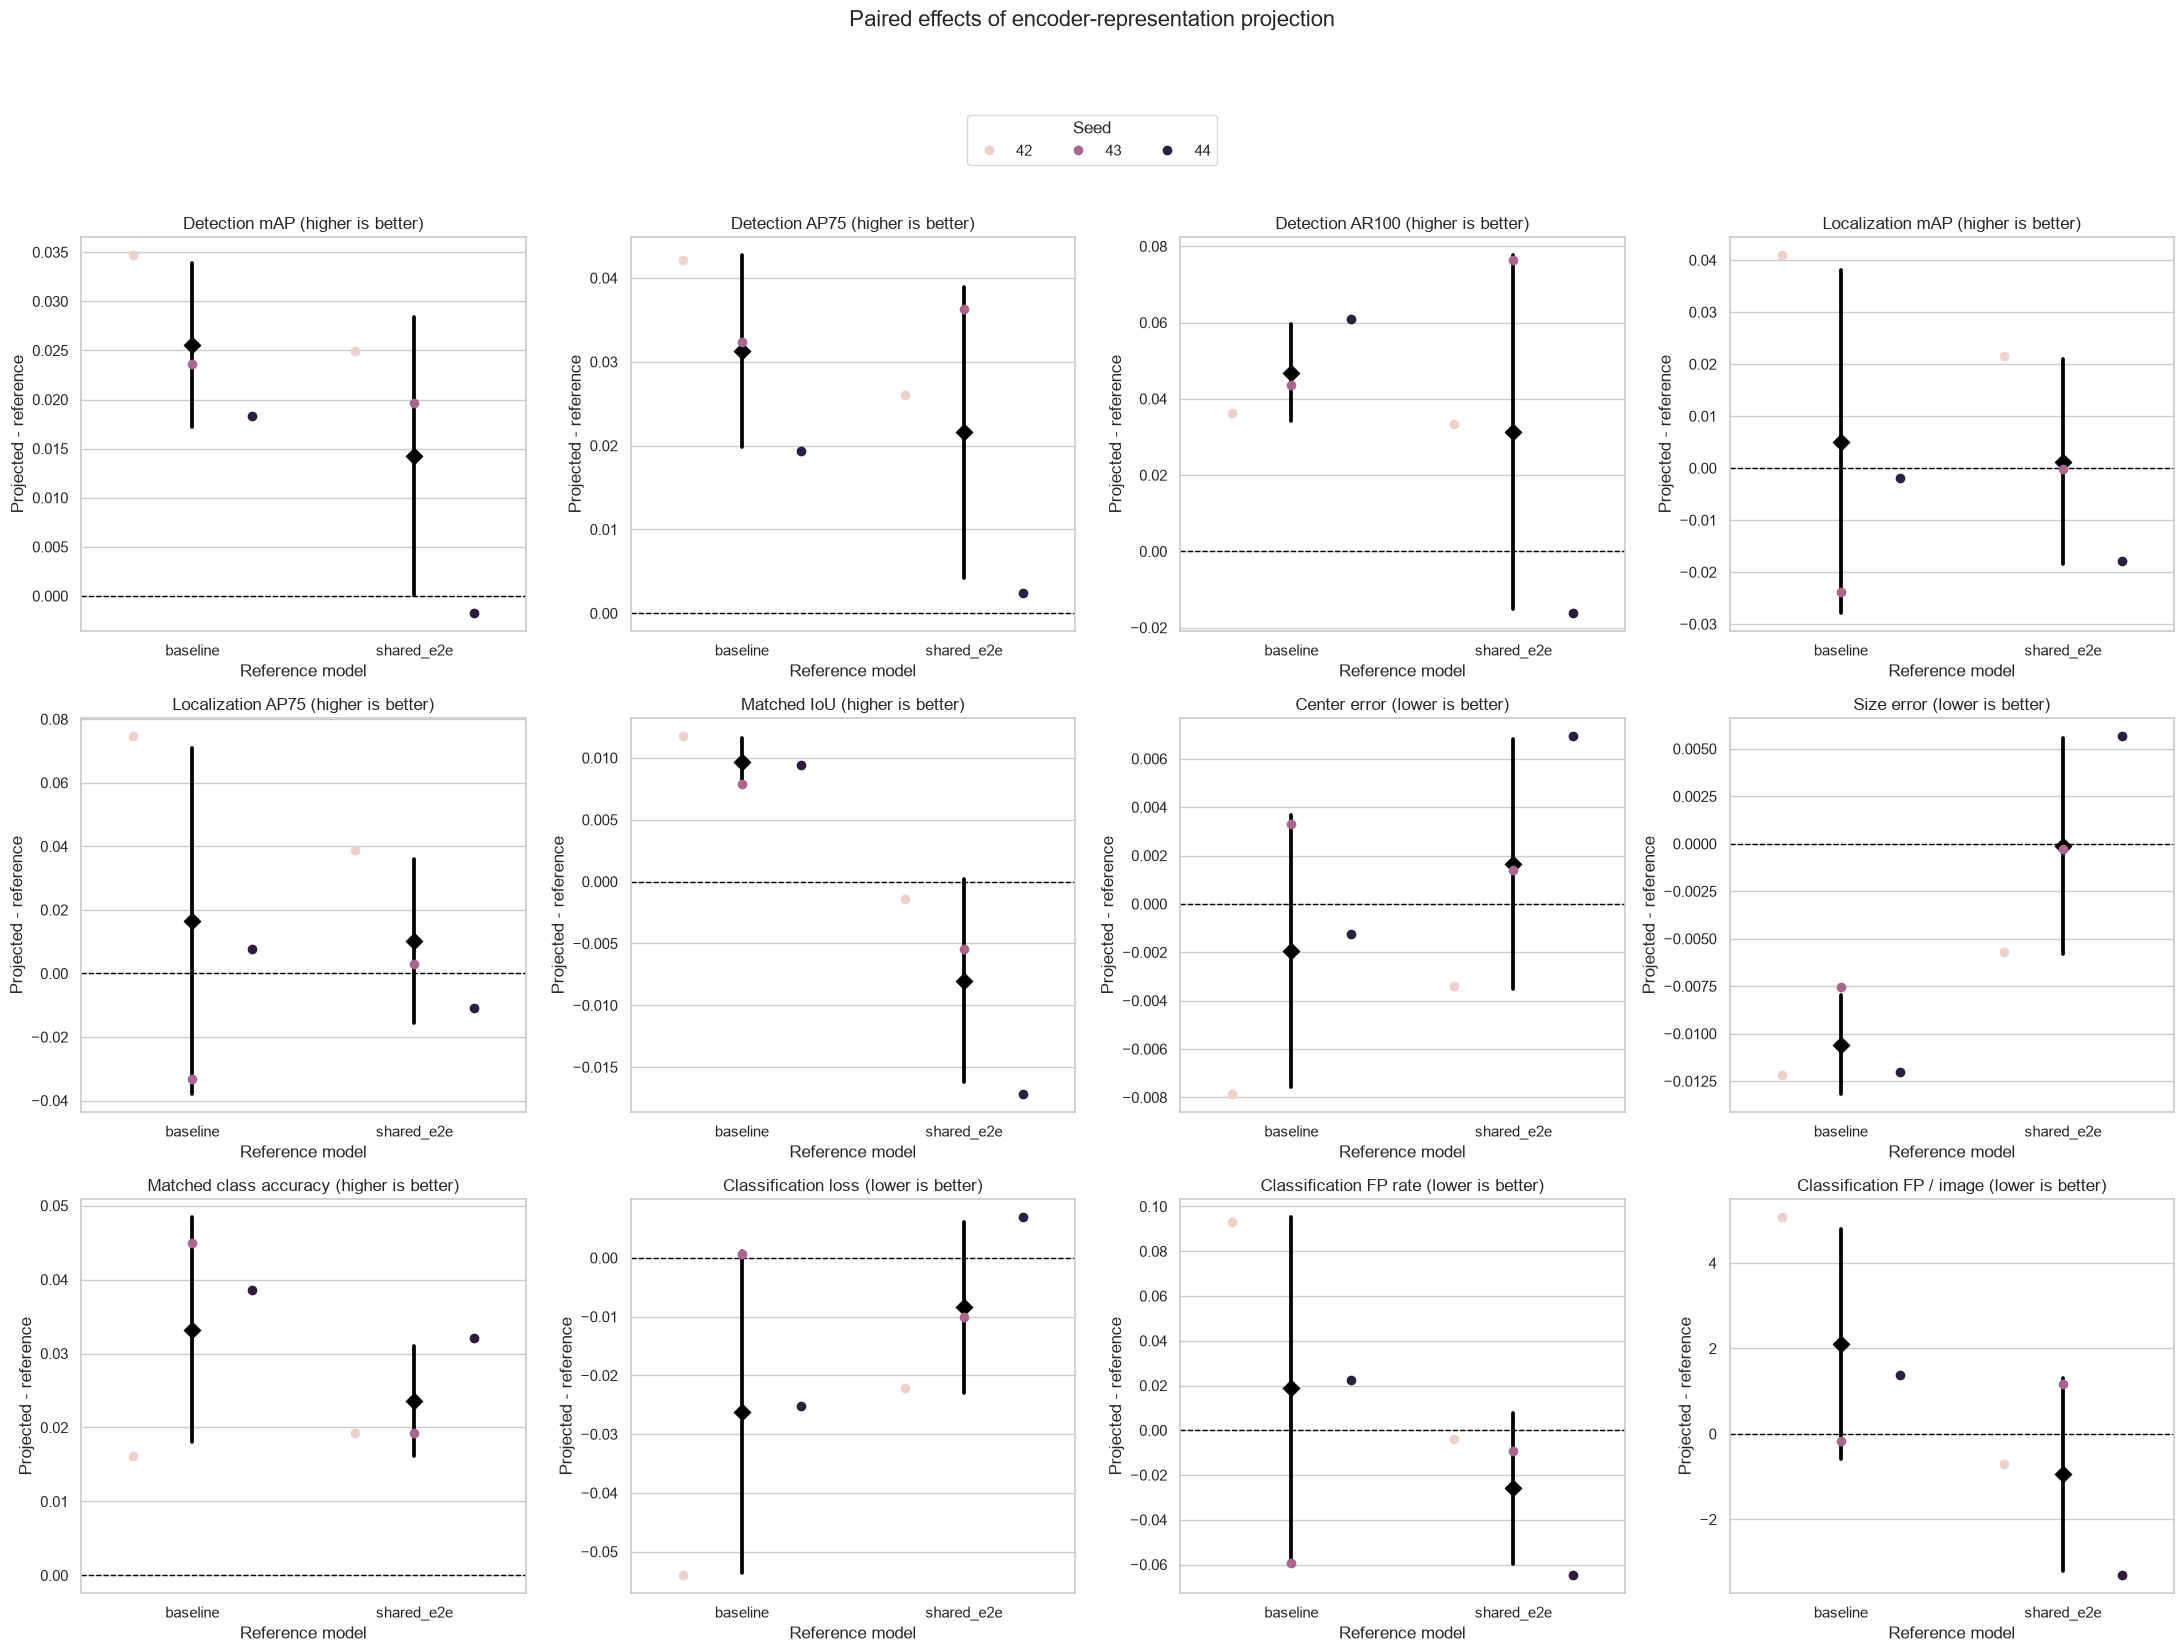

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projection_paired_delta_heatmap.png


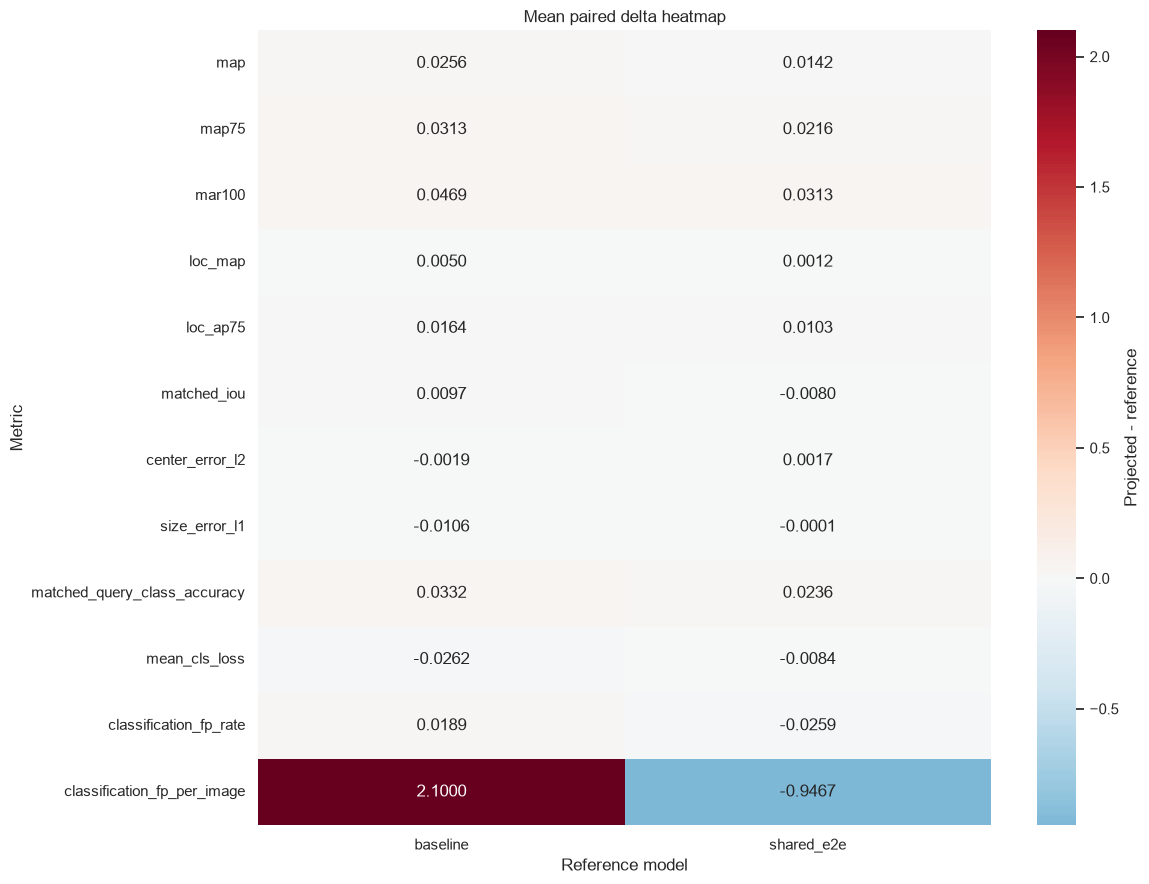

In [10]:
paired_specs = [
    ('map', 'Detection mAP', 'higher is better'),
    ('map75', 'Detection AP75', 'higher is better'),
    ('mar100', 'Detection AR100', 'higher is better'),
    ('loc_map', 'Localization mAP', 'higher is better'),
    ('loc_ap75', 'Localization AP75', 'higher is better'),
    ('matched_iou', 'Matched IoU', 'higher is better'),
    ('center_error_l2', 'Center error', 'lower is better'),
    ('size_error_l1', 'Size error', 'lower is better'),
    ('matched_query_class_accuracy', 'Matched class accuracy', 'higher is better'),
    ('mean_cls_loss', 'Classification loss', 'lower is better'),
    ('classification_fp_rate', 'Classification FP rate', 'lower is better'),
    ('classification_fp_per_image', 'Classification FP / image', 'lower is better'),
]
fig, axes = plt.subplots(3, 4, figsize=(22, 15))
for ax, (metric, title, direction) in zip(axes.flat, paired_specs):
    view = paired_delta_df[['reference', 'seed', metric]].rename(columns={metric: 'delta'})
    sns.stripplot(data=view, x='reference', y='delta', hue='seed', dodge=True, size=7, ax=ax)
    sns.pointplot(data=view, x='reference', y='delta', color='black', errorbar='sd', linestyle='none', markers='D', ax=ax)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(f'{title} ({direction})')
    ax.set_xlabel('Reference model')
    ax.set_ylabel('Projected - reference')
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(*axes.flat[0].get_legend_handles_labels(), title='Seed', loc='upper center', bbox_to_anchor=(0.5, 1.035), ncol=len(SEEDS))
fig.suptitle('Paired effects of encoder-representation projection', y=1.10, fontsize=16)
plt.tight_layout()
paired_figure_path = CONFIG.output_dir / 'shared_e2e_projection_paired_deltas.png'
fig.savefig(paired_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', paired_figure_path)
plt.show()

delta_means = paired_delta_df.groupby('reference')[[x[0] for x in paired_specs]].mean().T
plt.figure(figsize=(12, 9))
sns.heatmap(delta_means, cmap='RdBu_r', center=0, annot=True, fmt='.4f', cbar_kws={'label': 'Projected - reference'})
plt.title('Mean paired delta heatmap')
plt.xlabel('Reference model')
plt.ylabel('Metric')
plt.tight_layout()
delta_heatmap_path = CONFIG.output_dir / 'shared_e2e_projection_paired_delta_heatmap.png'
plt.savefig(delta_heatmap_path, dpi=180, bbox_inches='tight')
print('Saved:', delta_heatmap_path)
plt.show()

## 8. Localization scale and geometry diagnostics

This separates detector performance by object scale from matched-box geometry, which helps distinguish an AP gain from an actual localization-quality gain.

C:\Users\이노뎁\AppData\Local\Temp\ipykernel_8012\2157999420.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=scale_view, x='scale', y='score', hue='experiment', dodge=True, color='black', alpha=0.55, ax=axes[0, 0])


Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projection_localization_diagnostics.png


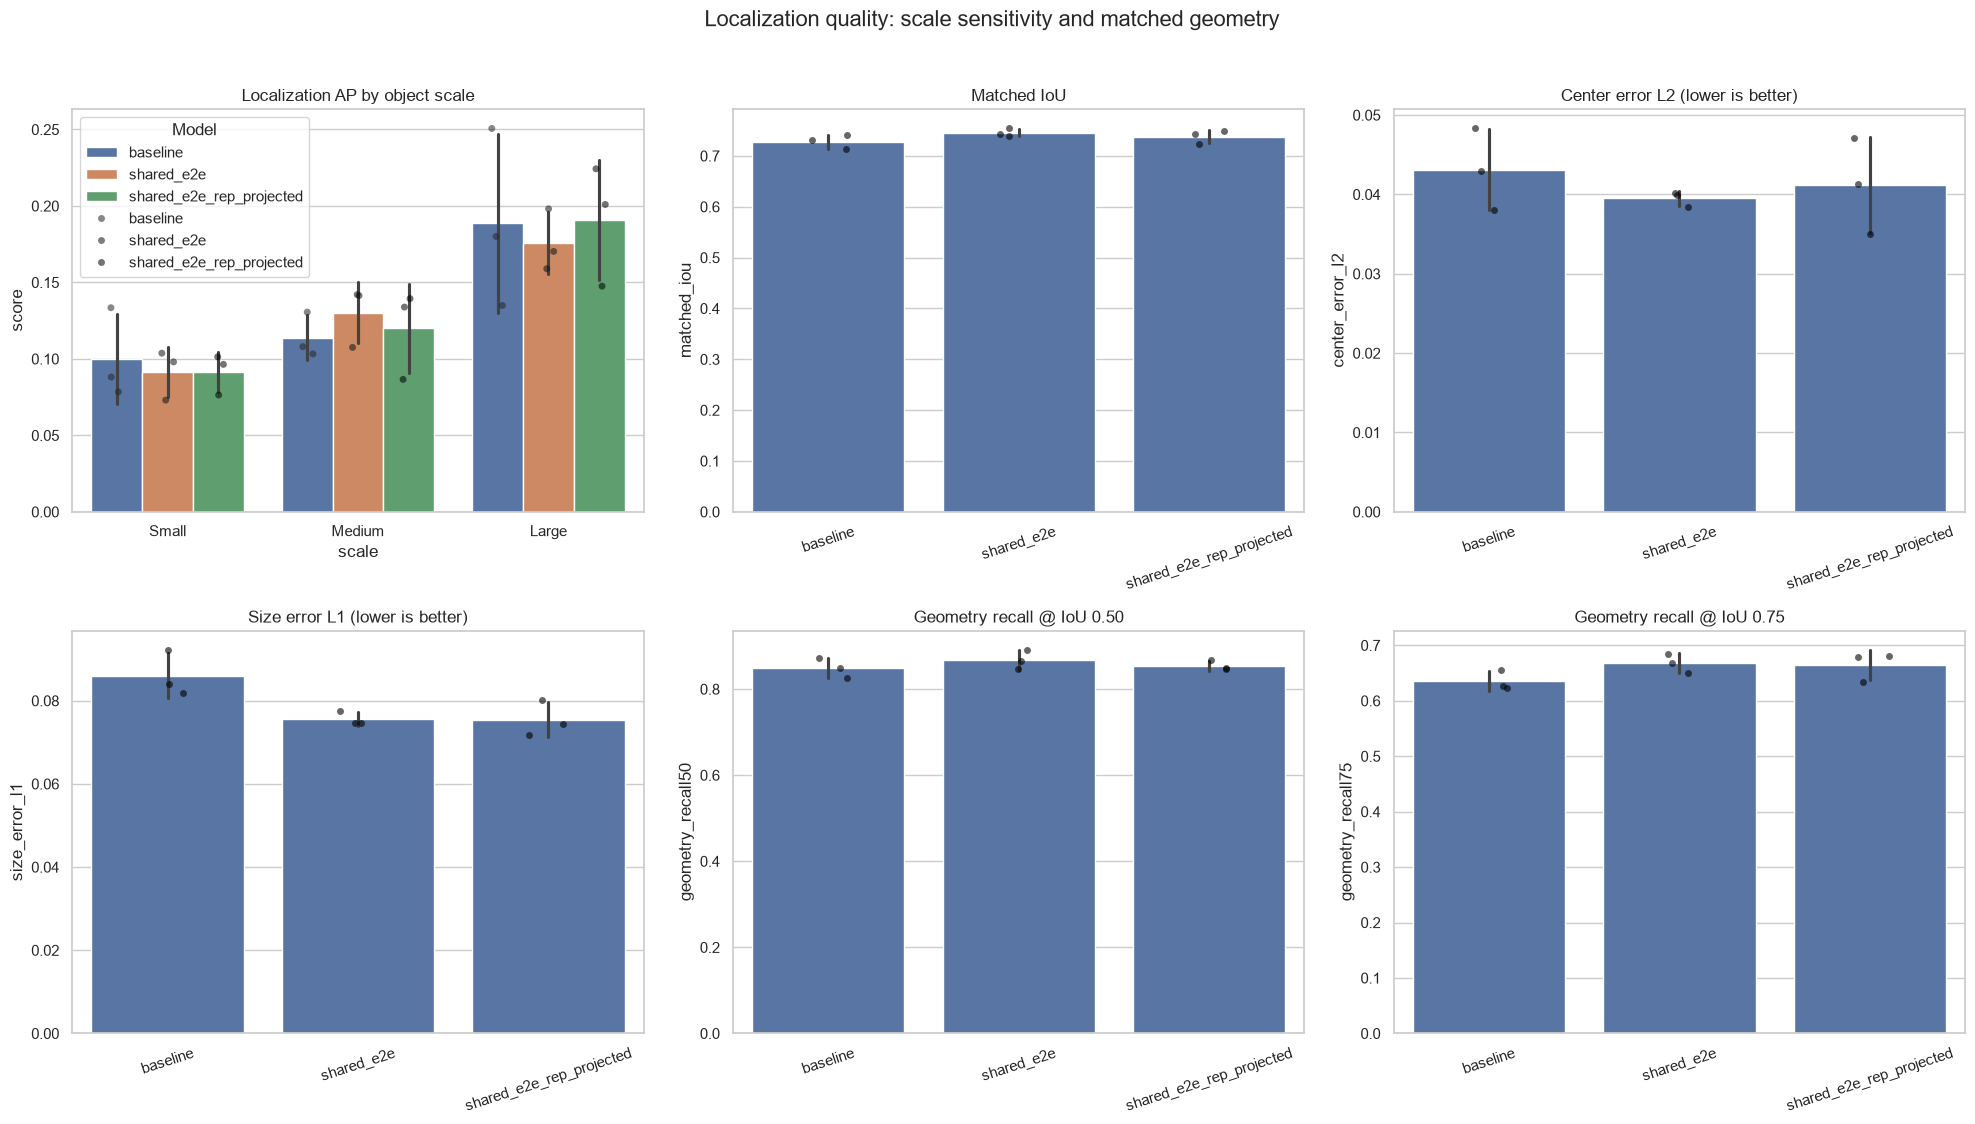

In [11]:
scale_metrics = ['loc_ap_small', 'loc_ap_medium', 'loc_ap_large']
geometry_specs = [
    ('matched_iou', 'Matched IoU'),
    ('center_error_l2', 'Center error L2 (lower is better)'),
    ('size_error_l1', 'Size error L1 (lower is better)'),
    ('geometry_recall50', 'Geometry recall @ IoU 0.50'),
    ('geometry_recall75', 'Geometry recall @ IoU 0.75'),
]
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
scale_view = results_df.melt(
    id_vars=['experiment', 'seed'], value_vars=scale_metrics,
    var_name='scale', value_name='score',
)
scale_view['scale'] = scale_view['scale'].str.replace('loc_ap_', '', regex=False).str.title()
sns.barplot(data=scale_view, x='scale', y='score', hue='experiment', errorbar='sd', ax=axes[0, 0])
sns.stripplot(data=scale_view, x='scale', y='score', hue='experiment', dodge=True, color='black', alpha=0.55, ax=axes[0, 0])
axes[0, 0].set_title('Localization AP by object scale')
axes[0, 0].legend(title='Model', loc='best')
for ax, (metric, title) in zip(axes.flat[1:], geometry_specs):
    sns.barplot(data=results_df, x='experiment', y=metric, errorbar='sd', ax=ax)
    sns.stripplot(data=results_df, x='experiment', y=metric, color='black', alpha=0.6, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=18)
fig.suptitle('Localization quality: scale sensitivity and matched geometry', y=1.02, fontsize=16)
plt.tight_layout()
localization_figure_path = CONFIG.output_dir / 'shared_e2e_projection_localization_diagnostics.png'
fig.savefig(localization_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', localization_figure_path)
plt.show()

## 9. Projection mechanism and cost diagnostics

The distribution plots use every logged optimization step for the representation-projected model; the cost panel uses the controlled projection-cost probe.

Saved: D:\gt-super\outputs\detr_gt_auxiliary\shared_e2e_projection_mechanism_diagnostics.png


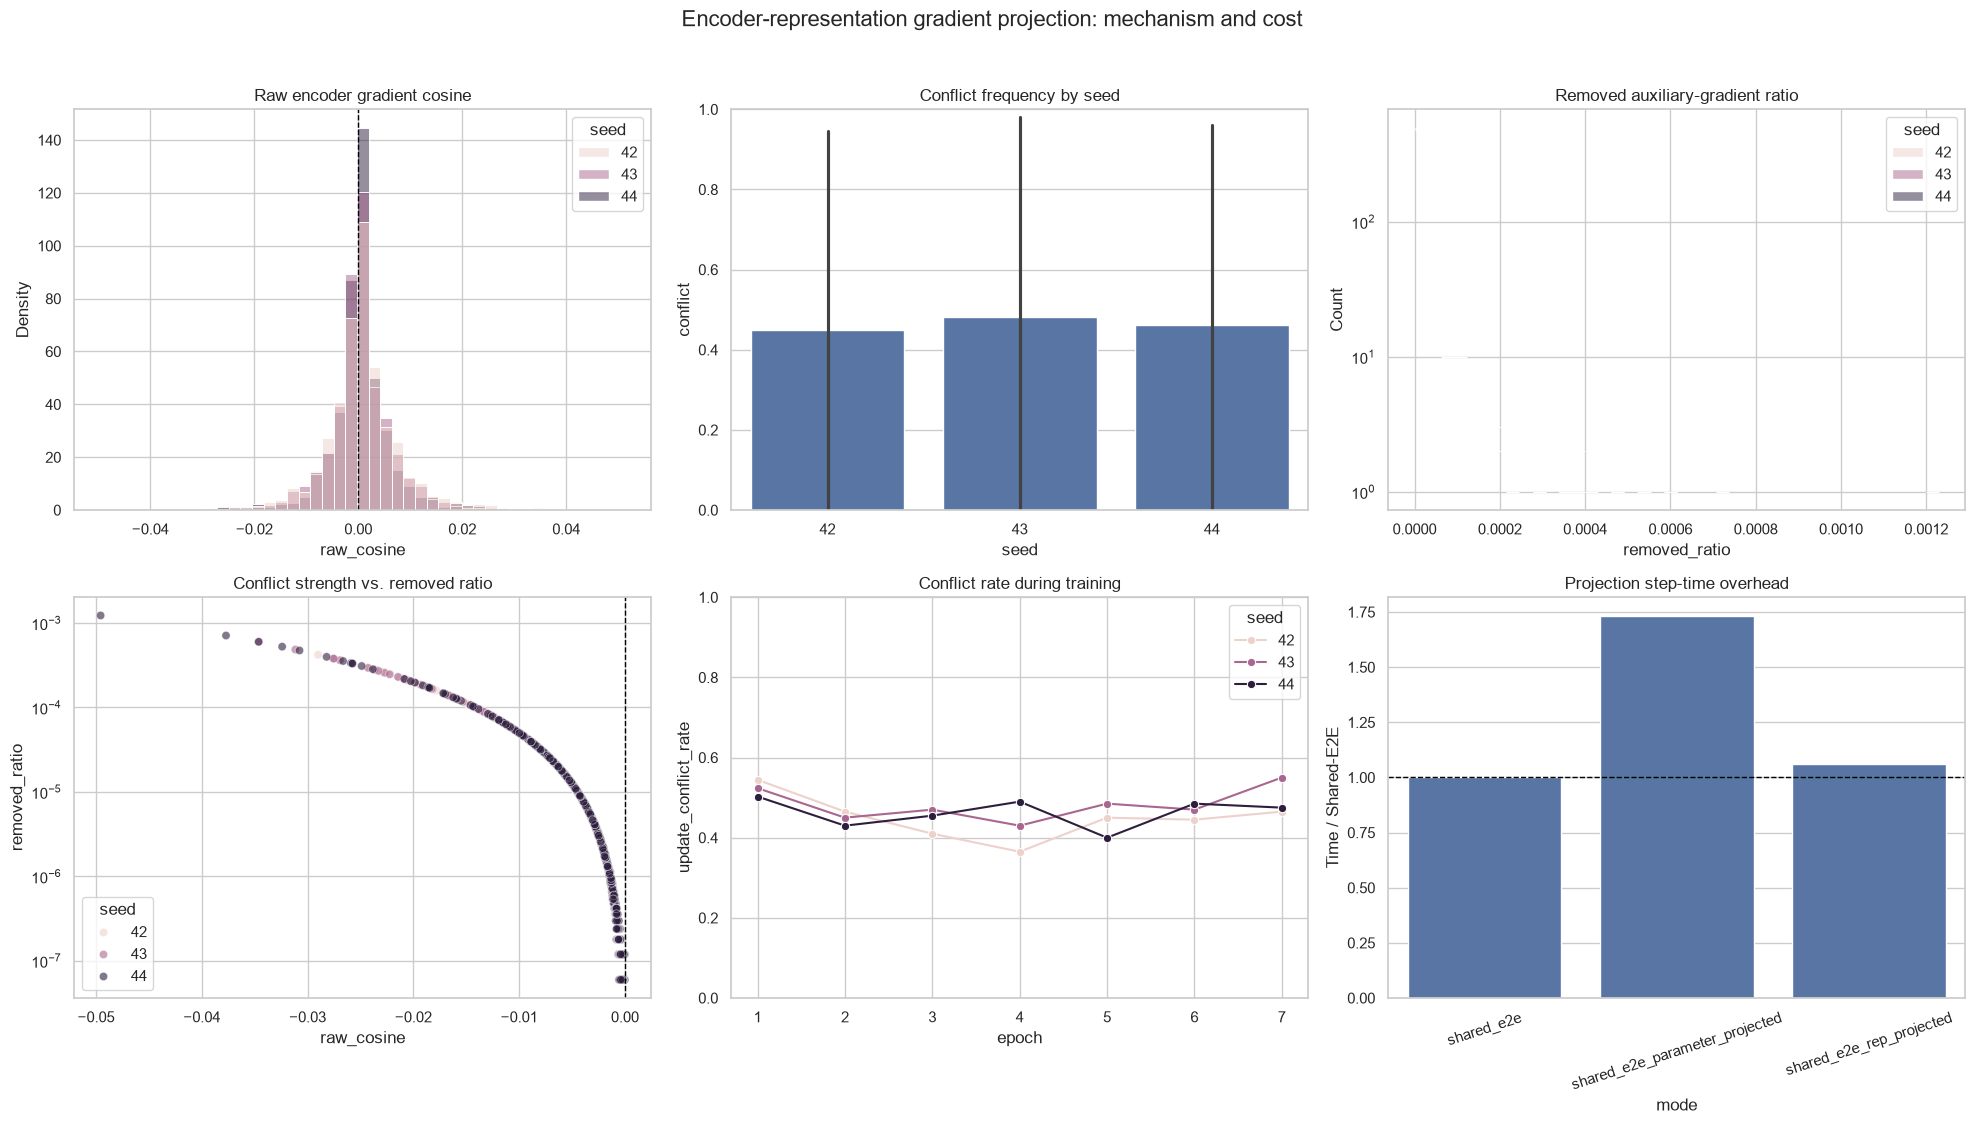

In [12]:
gradient_view = gradient_df.copy()
gradient_view['raw_cosine'] = gradient_view['enc_cls_aux_cosine_raw']
gradient_view['removed_ratio'] = gradient_view['projection_removed_ratio'].clip(lower=0)
gradient_view['projection_applied'] = gradient_view['projection_applied'].astype(bool)
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
sns.histplot(data=gradient_view, x='raw_cosine', hue='seed', bins=45, stat='density', common_norm=False, ax=axes[0, 0])
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Raw encoder gradient cosine')
conflict_view = gradient_view.assign(conflict=gradient_view['raw_cosine'] < 0)
sns.barplot(data=conflict_view, x='seed', y='conflict', errorbar='sd', ax=axes[0, 1])
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('Conflict frequency by seed')
removed_nonzero = gradient_view.query('projection_applied and removed_ratio > 0')
sns.histplot(data=removed_nonzero, x='removed_ratio', hue='seed', bins=40, log_scale=(False, True), ax=axes[0, 2])
axes[0, 2].set_title('Removed auxiliary-gradient ratio')
sns.scatterplot(data=removed_nonzero, x='raw_cosine', y='removed_ratio', hue='seed', alpha=0.6, ax=axes[1, 0])
axes[1, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Conflict strength vs. removed ratio')
sns.lineplot(data=mechanism_df, x='epoch', y='update_conflict_rate', hue='seed', marker='o', ax=axes[1, 1])
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title('Conflict rate during training')
cost_path = CONFIG.output_dir / 'shared_e2e_projection_cost_probe.csv'
if cost_path.exists():
    cost_df = pd.read_csv(cost_path)
    sns.barplot(data=cost_df, x='mode', y='time_over_shared', ax=axes[1, 2])
    axes[1, 2].axhline(1, color='black', linestyle='--', linewidth=1)
    axes[1, 2].tick_params(axis='x', rotation=18)
    axes[1, 2].set_ylabel('Time / Shared-E2E')
    axes[1, 2].set_title('Projection step-time overhead')
else:
    axes[1, 2].set_axis_off()
fig.suptitle('Encoder-representation gradient projection: mechanism and cost', y=1.02, fontsize=16)
plt.tight_layout()
mechanism_detail_path = CONFIG.output_dir / 'shared_e2e_projection_mechanism_diagnostics.png'
fig.savefig(mechanism_detail_path, dpi=180, bbox_inches='tight')
print('Saved:', mechanism_detail_path)
plt.show()